# Join Cohorts to Project Features

This notebook joins each donor's `first_project_id` to the matching project record. It reads the Projects file in chunks because the full file is too large to load comfortably. The goal is to add project context that was available at the first donation without leaking future information into the second-gift prediction.

In [2]:
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import zipfile
import pandas as pd

ARCHIVE = REPO / "data" / "raw" / "ICPSR_37898-V1.zip"
COHORTS_PATH = REPO / "data" / "processed" / "cohorts.parquet"
PROJECT_MEMBER = "ICPSR_37898/DS0003/37898-0003-Data.tsv"

# Confirm the processed cohort file exists before attempting the join.
if not COHORTS_PATH.exists():
    raise FileNotFoundError(
        f"Missing {COHORTS_PATH}. Place the team's cohorts.parquet there, then rerun this cell."
    )

cohorts = pd.read_parquet(COHORTS_PATH)
print("Cohort shape:", cohorts.shape)
print("Cohort columns:", cohorts.columns.tolist())

if "first_project_id" not in cohorts.columns:
    raise KeyError("cohorts.parquet must contain first_project_id")

cohorts["first_project_id"] = cohorts["first_project_id"].astype("string")
project_ids = set(cohorts["first_project_id"].dropna())
print(f"Unique first-project IDs to find: {len(project_ids):,}")

Cohort shape: (3277153, 15)
Cohort columns: ['donor_id', 'cohort_month', 'first_gift_amount', 'first_month_gifts', 'first_project_id', 'first_matched', 'first_teacher_referred', 'first_thank_you_packet', 'first_gift_card', 'donor_type', 'second_gift_amount', 'second_gift_count', 'gave_again', 'cohort', 'split']


Unique first-project IDs to find: 928,917


## Stream and filter the Projects file

These are candidate features. `PROJECT_STATUS_AS_OF_12_31_2019`, `DAYS_BETWEEN_POSTED_AND_COMPLE_1`, `THANKYOU_NOTE`, and `IMPACT_LETTER` are deliberately excluded because they contain information observed after the project was posted and may be unavailable at the donor's first gift.

In [3]:
project_keep = [
    "PROJECT_ID", "GRADE_LEVEL", "SUBJECT_CATEGORY", "SUBJECT_SUBCATEGORY",
    "OPTIONAL_SUBJECT_CATEGORY", "OPTIONAL_SUBJECT_SUBCATEGORY", "CATEGORY",
    "COST_OF_REQUESTED_RESOURCES", "VENDOR_SHIPPING_CHARGES",
    "PAYMENT_PROCESSING_CHARGES", "SALES_TAX", "FULFILLMENT_AND_LABOR_MATERIALS",
    "OPTIONAL_SUPPORT", "TOTAL_PRICE_EXCLUDING_OPTIONAL_1",
    "SCHOOL_PERCENTAGE_FREE_AND_RED_1", "STUDENTS_REACHED", "POSTED_MONTH",
    "SCHOOL_STATE", "TEACHER_ID"
]

matched_parts = []
with zipfile.ZipFile(ARCHIVE) as zf:
    with zf.open(PROJECT_MEMBER) as stream:
        for projects_chunk in pd.read_csv(
            stream,
            sep="\t",
            usecols=project_keep,
            dtype="string",
            chunksize=100_000,
        ):
            matched = projects_chunk[projects_chunk["PROJECT_ID"].isin(project_ids)]
            if not matched.empty:
                matched_parts.append(matched)

projects_for_cohorts = pd.concat(matched_parts, ignore_index=True)
print("Matched project rows:", len(projects_for_cohorts))
print("Unique matched project IDs:", projects_for_cohorts["PROJECT_ID"].nunique())
print("Unmatched cohort IDs:", len(project_ids - set(projects_for_cohorts["PROJECT_ID"])))

Matched project rows: 926619
Unique matched project IDs: 926619


Unmatched cohort IDs: 2298


## Merge and validate the relationship

`validate="many_to_one"` means many donor-cohort rows may point to one project, but each project ID must appear only once in the Projects table. An unexpected duplicate would need investigation before modeling.

In [4]:
projects_for_cohorts = projects_for_cohorts.rename(columns={"PROJECT_ID": "first_project_id"})

cohorts_with_projects = cohorts.merge(
    projects_for_cohorts,
    on="first_project_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

print(cohorts_with_projects["_merge"].value_counts())
print(
    f"Project match rate: "
    f"{(cohorts_with_projects['_merge'].eq('both').mean()):.2%}"
)

cohorts_with_projects = cohorts_with_projects.drop(columns="_merge")
cohorts_with_projects.head()

_merge
both          3268721
left_only        8432
right_only          0
Name: count, dtype: int64
Project match rate: 99.74%


,donor_id,cohort_month,first_gift_amount,first_month_gifts,first_project_id,first_matched,first_teacher_referred,first_thank_you_packet,first_gift_card,donor_type,...,PAYMENT_PROCESSING_CHARGES,SALES_TAX,FULFILLMENT_AND_LABOR_MATERIALS,OPTIONAL_SUPPORT,TOTAL_PRICE_EXCLUDING_OPTIONAL_1,SCHOOL_PERCENTAGE_FREE_AND_RED_1,STUDENTS_REACHED,POSTED_MONTH,SCHOOL_STATE,TEACHER_ID
0,0000023f507999464aa2b78875b7e5d6,153,10.0,1,9dd2b4a2f72980d4ca2f29347f15d161,False,False,False,False,citizen donor,...,4.48,0,30,58.76,332.98,95,30,2012-06,NY,c9a71076fed8e1a8adc5ab32e5a1f454
1,00000ce845c00cbf0686c992fc369df4,167,50.0,1,5bab6101eed588c396a59f6bd64274b6,True,True,True,False,citizen donor,...,22.65,104.19,30,296.26,1678.78,5,20,2013-12,GA,9344ae7fbb6f1979e992c1cd1d730c49
2,00002783bc5d108510f3f9666c8b1edd,193,99.0,1,9db61b1b1e43a7b256eec9b20b42d854,False,True,False,False,citizen donor,...,18,0,30,220.24,1248,49,4,2016-01,VA,521c6f95f6a30a6a42a022b7109b7bed
3,00002d44003ed46b066607c5455a999a,201,10.0,1,e2beb818569f66adaa4ced21ca299ac6,True,False,False,False,teacher,...,5.99,36.55,30,83.29,471.99,84,100,2016-10,CA,00002d44003ed46b066607c5455a999a
4,00002eb25d60a09c318efbd0797bffb5,188,50.0,1,702f713c52b632d490f3f63b75d22a45,True,True,False,False,citizen donor,...,6.45,0,30,82.31,466.41,95,140,2015-09,MA,542898959ff2db0b6945ee8e07f5147d


In [5]:
import numpy as np

## Create modeling features

Start with a small, interpretable set. Project cost is right-skewed, so use `log1p`. Keep the raw categorical fields for a later pipeline with one-hot encoding. Do not use post-outcome project fields.

In [6]:
numeric_features = [
    "COST_OF_REQUESTED_RESOURCES", "TOTAL_PRICE_EXCLUDING_OPTIONAL_1",
    "SCHOOL_PERCENTAGE_FREE_AND_RED_1", "STUDENTS_REACHED"
]
categorical_features = [
    "GRADE_LEVEL", "SUBJECT_CATEGORY", "SUBJECT_SUBCATEGORY",
    "CATEGORY", "SCHOOL_STATE"
]

for col in numeric_features:
    cohorts_with_projects[col] = pd.to_numeric(cohorts_with_projects[col], errors="coerce")

cohorts_with_projects["log_project_cost"] = (
    cohorts_with_projects["COST_OF_REQUESTED_RESOURCES"].clip(lower=0).pipe(np.log1p)
)

feature_columns = ["first_gift_amount", "log_project_cost"] + categorical_features + [
    "SCHOOL_PERCENTAGE_FREE_AND_RED_1", "STUDENTS_REACHED"
]
feature_columns = [col for col in feature_columns if col in cohorts_with_projects.columns]
cohorts_with_projects[feature_columns].head()

,first_gift_amount,log_project_cost,GRADE_LEVEL,SUBJECT_CATEGORY,SUBJECT_SUBCATEGORY,CATEGORY,SCHOOL_STATE,SCHOOL_PERCENTAGE_FREE_AND_RED_1,STUDENTS_REACHED
0,10.0,5.702114,Grades PreK-2,Special Needs,Special Needs,Supplies,NY,95,30
1,50.0,7.320487,Grades 3-5,Literacy,Literacy & Language,Technology,GA,5,20
2,99.0,7.09091,Grades 9-12,Civics & Government,History & Civics,Trips,VA,49,4
3,10.0,5.992589,Grades 6-8,Literacy,Literacy & Language,Books,CA,84,100
4,50.0,6.066015,Grades 6-8,Literacy,Literacy & Language,Books,MA,95,140


In [7]:
# Save the enriched cohort table for modeling.
OUTPUT_PATH = REPO / "data" / "processed" / "cohorts_with_projects.parquet"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
cohorts_with_projects.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")

Saved enriched cohort table


## Why are some cohort projects unmatched?

The join found 8,432 cohort rows without a matching project record. The following diagnostics examine whether those rows are concentrated in certain years, donor types, or ID patterns.

In [8]:
unmatched_ids = set(cohorts["first_project_id"].dropna()) - set(projects_for_cohorts["first_project_id"])
unmatched = cohorts[cohorts["first_project_id"].isin(unmatched_ids)].copy()
unmatched["cohort_year"] = unmatched["cohort"].str[:4]
unmatched["id_length"] = unmatched["first_project_id"].str.len()
unmatched["id_prefix"] = unmatched["first_project_id"].str[:4]

print(f"Unmatched cohort rows: {len(unmatched):,}")
print(f"Unique unmatched project IDs: {unmatched['first_project_id'].nunique():,}")
print("\nUnmatched rows by cohort year:")
print(unmatched.groupby("cohort_year").size().to_string())
print("\nUnmatched rows by donor type:")
print(unmatched["donor_type"].value_counts(dropna=False).to_string())
print("\nUnmatched first-gift amount summary:")
print(unmatched["first_gift_amount"].describe().round(2).to_string())
print("\nUnmatched ID lengths:")
print(unmatched["id_length"].value_counts(dropna=False).sort_index().to_string())

Unmatched cohort rows: 8,432
Unique unmatched project IDs: 2,298

Unmatched rows by cohort year:
cohort_year
2005      27
2006      31
2007      62
2008     113
2009     312
2010     499
2011    1002
2012     608
2013     603
2014     719
2015    1043
2016    1200
2017    1077
2018    1136

Unmatched rows by donor type:
donor_type
citizen donor    7651
teacher           777
organization        4

Unmatched first-gift amount summary:
count       8432.00
mean         632.85
std        51747.72
min            1.00
25%           20.00
50%           25.00
75%           50.00
max      4751745.33

Unmatched ID lengths:
id_length
32    8432


In [9]:
comparison = pd.DataFrame({
    "matched": cohorts["first_project_id"].isin(set(projects_for_cohorts["first_project_id"])),
    "gave_again": cohorts["gave_again"].astype(bool),
    "first_gift_amount": cohorts["first_gift_amount"],
    "second_gift_amount": cohorts["second_gift_amount"],
    "donor_type": cohorts["donor_type"],
})
comparison["group"] = comparison["matched"].map({True: "matched", False: "unmatched"})
print(comparison.groupby("group").agg(
    donors=("matched", "size"),
    repeat_rate=("gave_again", "mean"),
    median_first_gift=("first_gift_amount", "median"),
    total_second_gift=("second_gift_amount", "sum"),
).round(3).to_string())

print("\nUnmatched project IDs with the most cohort rows:")
print(unmatched["first_project_id"].value_counts().head(10).to_string())

            donors  repeat_rate  median_first_gift  total_second_gift
group                                                                
matched    3268721        0.158               25.0       2.481066e+08
unmatched     8432        0.149               25.0       1.213488e+06

Unmatched project IDs with the most cohort rows:
first_project_id
628e0107f480dd3fb9e02dcaf4b98bf7    82
cba9fe97df2aada550f85d59b4142b19    82
b1481757b3fa9c2540492e2b82c0ed2e    49
c86bfd34e20f2cef17a3c08a5e0dc01e    35
d7a4acb94ee3778b7b47062066b719db    33
07f55b6456e55eda6189e61e0c5a2200    30
499a705e47f6daa563edacc8daefbc81    29
71a72ad88e2caf75548a1a6dfdb1f322    29
ce1a1f9cef1509e486dac8c53f723f51    26
d410599b530880875aa5429e1cd3a77b    25


## Finding and modeling recommendation

The unmatched IDs are not malformed keys: all are 32 characters, and they occur across many cohort years rather than only at the beginning or end of the data. They are present in donations but absent from the public-use Projects file.

The unmatched group is small and does not look materially different on the current outcome checks. Keep these cohort rows, add a missing-project indicator, and impute project features within the training data. Report the 99.74% project match rate. Do not silently convert missing project attributes into meaningful categories without tracking this indicator.

In [10]:
project_key_set = set(projects_for_cohorts["first_project_id"])
cohorts_with_projects["project_record_missing"] = ~cohorts_with_projects["first_project_id"].isin(project_key_set)
cohorts_with_projects.to_parquet(OUTPUT_PATH, index=False)
print(cohorts_with_projects["project_record_missing"].value_counts())
print(f"Updated: {OUTPUT_PATH}")

project_record_missing
False    3268721
True        8432
Name: count, dtype: int64
Updated enriched cohort table


## Matched versus unmatched: broader comparison

This table checks whether missing project records are concentrated in particular donor, cohort, or outcome segments.

In [11]:
match_flag = cohorts["first_project_id"].isin(project_key_set)
comparison = cohorts.assign(project_match=match_flag, cohort_year=cohorts["cohort"].str[:4])

numeric_compare = [
    "cohort_month", "first_gift_amount", "first_month_gifts",
    "second_gift_amount", "second_gift_count", "gave_again"
]
summary = comparison.groupby("project_match")[numeric_compare].agg(["mean", "median", "quantile"])
# Keep a compact, interpretable summary rather than displaying every aggregation level.
compact = comparison.groupby("project_match")[numeric_compare].agg(
    ["mean", "median"]
).round(2)
print("Numeric and outcome comparison:")
print(compact.to_string())

for col in ["cohort_year", "split", "donor_type", "first_matched",
            "first_teacher_referred", "first_thank_you_packet", "first_gift_card"]:
    shares = pd.crosstab(comparison[col], comparison["project_match"], normalize="columns")
    shares.columns = ["unmatched_share" if c is False else "matched_share" for c in shares.columns]
    shares["difference_pp"] = (shares.get("unmatched_share", 0) - shares.get("matched_share", 0)) * 100
    print(f"\n{col} distribution (percentage points: unmatched minus matched):")
    print((shares.sort_values("difference_pp", ascending=False) * [100, 100, 1]).round(2).to_string())

Numeric and outcome comparison:
              cohort_month        first_gift_amount        first_month_gifts        second_gift_amount        second_gift_count        gave_again       
                      mean median              mean median              mean median               mean median              mean median       mean median
project_match                                                                                                                                           
False               175.95  183.0            632.85   25.0              1.93    1.0             143.91    0.0              0.59    0.0       0.15    0.0
True                176.91  183.0            118.86   25.0              1.51    1.0              75.90    0.0              0.93    0.0       0.16    0.0



cohort_year distribution (percentage points: unmatched minus matched):
             unmatched_share  matched_share  difference_pp
cohort_year                                               
2011                   11.88           9.69           2.19
2015                   12.37          10.34           2.03
2009                    3.70           2.34           1.36
2016                   14.23          13.24           0.99
2005                    0.32           0.10           0.22
2006                    0.37           0.39          -0.02
2003                    0.00           0.05          -0.05
2004                    0.00           0.07          -0.07
2008                    1.34           1.58          -0.24
2017                   12.77          13.04          -0.27
2010                    5.92           6.25          -0.33
2007                    0.74           1.11          -0.37
2014                    8.53           8.91          -0.38
2013                    7.15           8.15


donor_type distribution (percentage points: unmatched minus matched):
               unmatched_share  matched_share  difference_pp
donor_type                                                  
citizen donor            90.74          90.68           0.06
teacher                   9.21           9.22          -0.01
organization              0.05           0.10          -0.05

first_matched distribution (percentage points: unmatched minus matched):
               unmatched_share  matched_share  difference_pp
first_matched                                               
True                     28.39          27.34           1.05
False                    71.61          72.66          -1.05



first_teacher_referred distribution (percentage points: unmatched minus matched):
                        unmatched_share  matched_share  difference_pp
first_teacher_referred                                               
False                             56.63          55.07           1.55
True                              43.37          44.93          -1.55

first_thank_you_packet distribution (percentage points: unmatched minus matched):
                        unmatched_share  matched_share  difference_pp
first_thank_you_packet                                               
False                             90.45          89.75           0.71
True                               9.55          10.25          -0.71



first_gift_card distribution (percentage points: unmatched minus matched):
                 unmatched_share  matched_share  difference_pp
first_gift_card                                               
False                      77.06          76.37           0.69
True                       22.94          23.63          -0.69


## Relationship between first and second donations

There are two separate questions:

1. Does first-gift size relate to whether a donor gives again?
2. Among donors who return, does first-gift size relate to the amount of the second-gift window?

The second question excludes donors with no second gift, because their second-gift amount is structurally zero.

In [12]:
from scipy.stats import pointbiserialr, spearmanr, pearsonr

analysis = cohorts[[
    "first_gift_amount", "first_month_gifts", "gave_again", "second_gift_amount"
]].copy()
analysis["log_first_gift"] = np.log1p(analysis["first_gift_amount"])
analysis["log_second_gift"] = np.log1p(analysis["second_gift_amount"])

returners = analysis[analysis["gave_again"].eq(1) & analysis["second_gift_amount"].gt(0)].copy()

print("First-gift size versus returning:")
print(f"Point-biserial correlation: {pointbiserialr(analysis['gave_again'], analysis['log_first_gift']).statistic:.3f}")
print(f"First-gift size median, non-returners: ${analysis.loc[analysis.gave_again.eq(0), 'first_gift_amount'].median():,.2f}")
print(f"First-gift size median, returners: ${analysis.loc[analysis.gave_again.eq(1), 'first_gift_amount'].median():,.2f}")
print(f"Returners: {len(returners):,} of {len(analysis):,} ({len(returners) / len(analysis):.1%})")

print("\nFirst-gift size versus second-gift amount among returners:")
print(f"Pearson correlation on log amounts: {pearsonr(returners['log_first_gift'], returners['log_second_gift']).statistic:.3f}")
print(f"Spearman rank correlation: {spearmanr(returners['first_gift_amount'], returners['second_gift_amount']).statistic:.3f}")
print(f"Median first gift among returners: ${returners['first_gift_amount'].median():,.2f}")
print(f"Median subsequent amount among returners: ${returners['second_gift_amount'].median():,.2f}")

First-gift size versus returning:
Point-biserial correlation: 0.127
First-gift size median, non-returners: $25.00
First-gift size median, returners: $50.00
Returners: 517,465 of 3,277,153 (15.8%)

First-gift size versus second-gift amount among returners:
Pearson correlation on log amounts: 0.554


Spearman rank correlation: 0.516
Median first gift among returners: $50.00
Median subsequent amount among returners: $50.00


## Binned relationship plots

Deciles make the relationship easier to interpret than a raw scatterplot dominated by a few very large gifts.

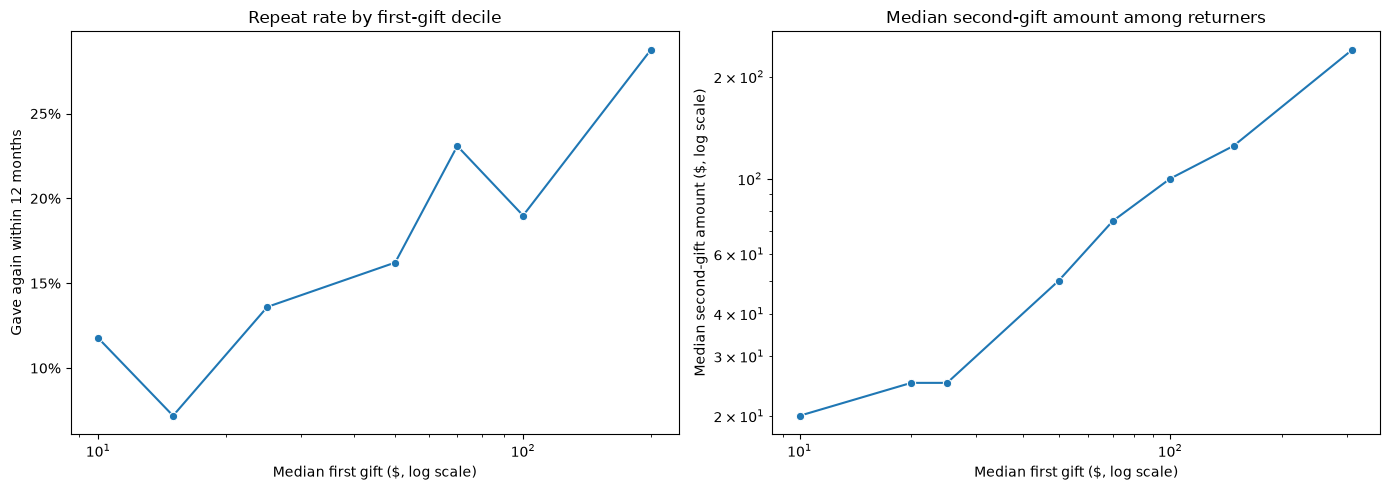

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_analysis = analysis.copy()
plot_analysis["gift_decile"] = pd.qcut(
    plot_analysis["first_gift_amount"], q=10, duplicates="drop"
)

deciles = plot_analysis.groupby("gift_decile", observed=True).agg(
    median_first_gift=("first_gift_amount", "median"),
    repeat_rate=("gave_again", "mean"),
    donors=("gave_again", "size"),
)
returner_deciles = returners.copy()
returner_deciles["gift_decile"] = pd.qcut(
    returner_deciles["first_gift_amount"], q=10, duplicates="drop"
)
second_by_decile = returner_deciles.groupby("gift_decile", observed=True).agg(
    median_first_gift=("first_gift_amount", "median"),
    median_second_gift=("second_gift_amount", "median"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=deciles.reset_index(), x="median_first_gift", y="repeat_rate", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].set_title("Repeat rate by first-gift decile")
axes[0].set_xlabel("Median first gift ($, log scale)")
axes[0].set_ylabel("Gave again within 12 months")

sns.lineplot(data=second_by_decile.reset_index(), x="median_first_gift", y="median_second_gift", marker="o", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Median second-gift amount among returners")
axes[1].set_xlabel("Median first gift ($, log scale)")
axes[1].set_ylabel("Median second-gift amount ($, log scale)")
plt.tight_layout()
plt.show()

## Multivariate associations with project features

A multivariate model estimates the association of each feature while holding the other included features constant. This is descriptive association, not proof that changing a project feature would cause more donations.

To keep exploratory computation manageable, this uses a reproducible 200,000-row sample from the training cohorts. The holdout remains untouched.

In [14]:
from sklearn.linear_model import LogisticRegression
from patsy import dmatrices

model_columns = [
    "gave_again", "second_gift_amount", "first_gift_amount", "first_month_gifts",
    "COST_OF_REQUESTED_RESOURCES", "STUDENTS_REACHED",
    "SCHOOL_PERCENTAGE_FREE_AND_RED_1", "project_record_missing",
    "GRADE_LEVEL", "SUBJECT_CATEGORY", "SUBJECT_SUBCATEGORY", "CATEGORY", "SCHOOL_STATE"
]
model_data = cohorts_with_projects.loc[
    cohorts_with_projects["split"].eq("train"), model_columns
].copy()
model_data = model_data.sample(n=min(200_000, len(model_data)), random_state=8496).copy()
model_data["log_first_gift"] = np.log1p(pd.to_numeric(model_data["first_gift_amount"], errors="coerce").clip(lower=0))
model_data["log_project_cost"] = np.log1p(pd.to_numeric(model_data["COST_OF_REQUESTED_RESOURCES"], errors="coerce").clip(lower=0))

for col in ["STUDENTS_REACHED", "SCHOOL_PERCENTAGE_FREE_AND_RED_1", "first_month_gifts", "log_first_gift", "log_project_cost"]:
    model_data[col] = pd.to_numeric(model_data[col], errors="coerce")
    model_data[col] = model_data[col].fillna(model_data[col].median())
model_data["project_record_missing"] = model_data["project_record_missing"].fillna(False).astype(int)
for col in ["GRADE_LEVEL", "SUBJECT_CATEGORY", "SUBJECT_SUBCATEGORY", "CATEGORY", "SCHOOL_STATE"]:
    model_data[col] = model_data[col].fillna("Missing").astype(str)

formula = (
    "gave_again ~ log_first_gift + first_month_gifts + log_project_cost "
    "+ STUDENTS_REACHED + SCHOOL_PERCENTAGE_FREE_AND_RED_1 "
    "+ project_record_missing + C(GRADE_LEVEL) + C(SUBJECT_CATEGORY) "
    "+ C(SUBJECT_SUBCATEGORY) + C(CATEGORY) + C(SCHOOL_STATE)"
)
y, X = dmatrices(formula, model_data, return_type="dataframe")
regularized_return_model = LogisticRegression(C=1.0, penalty="l2", solver="liblinear", max_iter=200)
regularized_return_model.fit(X.iloc[:, 1:], y.iloc[:, 0])

coef = pd.Series(regularized_return_model.coef_[0], index=X.columns[1:])
key_terms = ["log_first_gift", "first_month_gifts", "log_project_cost",
             "STUDENTS_REACHED", "SCHOOL_PERCENTAGE_FREE_AND_RED_1",
             "project_record_missing"]
return_results = pd.DataFrame({
    "coefficient": coef.loc[key_terms],
    "odds_ratio": np.exp(coef.loc[key_terms]),
})
print("Regularized multivariate association with giving again:")
return_results.round(4)

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Regularized multivariate association with giving again:


,coefficient,odds_ratio
log_first_gift,0.3016,1.3520
first_month_gifts,0.0613,1.0633
log_project_cost,-0.1209,0.8861
STUDENTS_REACHED,0.0001,1.0001
SCHOOL_PERCENTAGE_FREE_AND_RED_1,-0.0007,0.9993
project_record_missing,-0.1536,0.8576


In [15]:
# Among returners, model the amount of subsequent giving on a log scale.
amount_data = model_data.loc[model_data["gave_again"].eq(1) & model_data["second_gift_amount"].gt(0)].copy()
amount_data["log_second_gift"] = np.log1p(amount_data["second_gift_amount"])
amount_model = smf.ols(
    formula.replace("gave_again", "log_second_gift"), data=amount_data
).fit(cov_type="HC1")

amount_results = pd.DataFrame({
    "coefficient": amount_model.params.loc[key_terms],
    "p_value": amount_model.pvalues.loc[key_terms],
})
print("Association with subsequent amount among returners:")
amount_results.round(4)

NameError: name 'smf' is not defined

## Direct analysis of project features

The following section reports project-feature associations explicitly rather than hiding categorical variables inside model coefficients. Numeric features use Spearman correlations; categorical features show repeat rates by category with a minimum group size to avoid unstable tiny groups.

In [24]:
from scipy.stats import spearmanr

project_numeric = [
    "COST_OF_REQUESTED_RESOURCES", "VENDOR_SHIPPING_CHARGES",
    "PAYMENT_PROCESSING_CHARGES", "SALES_TAX", "FULFILLMENT_AND_LABOR_MATERIALS",
    "OPTIONAL_SUPPORT", "TOTAL_PRICE_EXCLUDING_OPTIONAL_1",
    "SCHOOL_PERCENTAGE_FREE_AND_RED_1", "STUDENTS_REACHED"
]
project_categorical = [
    "GRADE_LEVEL", "SUBJECT_CATEGORY", "SUBJECT_SUBCATEGORY",
    "OPTIONAL_SUBJECT_CATEGORY", "OPTIONAL_SUBJECT_SUBCATEGORY",
    "CATEGORY", "SCHOOL_STATE"
]

project_analysis = cohorts_with_projects.loc[
    cohorts_with_projects["split"].eq("train")
].sample(n=200_000, random_state=8496).copy()
project_analysis["log_second_gift"] = np.log1p(
    pd.to_numeric(project_analysis["second_gift_amount"], errors="coerce").clip(lower=0)
)

numeric_rows = []
for col in project_numeric:
    x = pd.to_numeric(project_analysis[col], errors="coerce")
    valid = x.notna()
    r_return = spearmanr(x[valid], project_analysis.loc[valid, "gave_again"]).statistic
    ret = project_analysis["gave_again"].eq(1) & project_analysis["second_gift_amount"].gt(0) & valid
    r_amount = spearmanr(x[ret], project_analysis.loc[ret, "second_gift_amount"]).statistic
    numeric_rows.append({
        "feature": col,
        "n": int(valid.sum()),
        "spearman_with_return": r_return,
        "spearman_with_amount_among_returners": r_amount,
    })

print("Numeric project-feature associations:")
print(pd.DataFrame(numeric_rows).sort_values("spearman_with_return", key=abs, ascending=False).round(3).to_string(index=False))

for col in project_categorical:
    grouped = project_analysis.assign(**{col: project_analysis[col].fillna("Missing").astype(str)})
    rates = grouped.groupby(col).agg(
        donors=("gave_again", "size"),
        repeat_rate=("gave_again", "mean"),
        median_first_gift=("first_gift_amount", "median"),
    )
    rates = rates[rates["donors"] >= 500].sort_values("repeat_rate")
    print(f"\n{col}: lowest and highest repeat rates among groups with at least 500 donors")
    print(pd.concat([rates.head(3), rates.tail(3)]).round(3).to_string())

## Binary indicators for project fields

For categorical variables, each category becomes a yes/no indicator. For monetary fields, we create indicators for whether a charge or optional support amount is present. The reported correlation is point-biserial correlation with `gave_again`.

In [25]:
from scipy.stats import pointbiserialr

binary_data = cohorts_with_projects.loc[
    cohorts_with_projects["split"].eq("train")
].sample(n=200_000, random_state=8496).copy()
binary_data["gave_again"] = binary_data["gave_again"].astype(int)
return_mask = binary_data["gave_again"].eq(1) & binary_data["second_gift_amount"].gt(0)

binary_rows = []

def add_binary_result(name, indicator):
    indicator = pd.Series(indicator, index=binary_data.index).fillna(False).astype(int)
    if indicator.nunique() < 2 or indicator.sum() < 500 or (1 - indicator).sum() < 500:
        return
    r_return = pointbiserialr(indicator, binary_data["gave_again"]).statistic
    valid_returners = return_mask & indicator.notna()
    if valid_returners.sum() >= 100:
        r_amount = pointbiserialr(
            indicator[valid_returners],
            np.log1p(binary_data.loc[valid_returners, "second_gift_amount"]),
        ).statistic
    else:
        r_amount = np.nan
    binary_rows.append({
        "indicator": name,
        "n_yes": int(indicator.sum()),
        "share_yes": indicator.mean(),
        "repeat_rate_yes": binary_data.loc[indicator.eq(1), "gave_again"].mean(),
        "repeat_rate_no": binary_data.loc[indicator.eq(0), "gave_again"].mean(),
        "corr_with_return": r_return,
        "corr_with_amount_returners": r_amount,
    })

for col in project_categorical:
    values = binary_data[col].fillna("Missing").astype(str)
    for value, n in values.value_counts().items():
        if n >= 500:
            add_binary_result(f"{col}={value}", values.eq(value))

charge_fields = [
    "VENDOR_SHIPPING_CHARGES", "PAYMENT_PROCESSING_CHARGES", "SALES_TAX",
    "FULFILLMENT_AND_LABOR_MATERIALS", "OPTIONAL_SUPPORT"
]
for col in charge_fields:
    amount = pd.to_numeric(binary_data[col], errors="coerce")
    add_binary_result(f"{col}>0", amount.gt(0))

binary_results = pd.DataFrame(binary_rows).sort_values(
    "corr_with_return", key=abs, ascending=False
)
print("Strongest binary associations with returning:")
print(binary_results.head(20).round(3).to_string(index=False))

print("\nWeakest binary associations with returning:")
print(binary_results.tail(10).sort_values("corr_with_return").round(3).to_string(index=False))

## Interaction terms

An interaction asks whether one feature changes the relationship between another feature and repeat behavior. For example, `CATEGORY=Technology` may perform differently for early-grade projects than for high-school projects, or first-gift size may matter differently across project categories.

In [26]:
interaction_data = cohorts_with_projects.loc[
    cohorts_with_projects["split"].eq("train")
].sample(n=200_000, random_state=8496).copy()

for col in ["GRADE_LEVEL", "SUBJECT_CATEGORY", "CATEGORY", "SCHOOL_STATE"]:
    interaction_data[col] = interaction_data[col].fillna("Missing").astype(str)

interaction_data["gift_decile"] = pd.qcut(
    interaction_data["first_gift_amount"], q=10, duplicates="drop", labels=False
).astype(str)

interaction_pairs = [
    ("CATEGORY", "GRADE_LEVEL"),
    ("SUBJECT_CATEGORY", "GRADE_LEVEL"),
    ("CATEGORY", "gift_decile"),
    ("SCHOOL_STATE", "CATEGORY"),
]

interaction_results = []
for left, right in interaction_pairs:
    name = f"{left} x {right}"
    cells = interaction_data[left] + " | " + interaction_data[right]
    cell_table = pd.DataFrame({"cell": cells, "gave_again": interaction_data["gave_again"]}).groupby("cell").agg(
        donors=("gave_again", "size"),
        repeat_rate=("gave_again", "mean"),
    )
    cell_table = cell_table[cell_table["donors"] >= 500]
    if not cell_table.empty:
        low = cell_table["repeat_rate"].idxmin()
        high = cell_table["repeat_rate"].idxmax()
        interaction_results.append({
            "interaction": name,
            "lowest_cell": low,
            "lowest_rate": cell_table.loc[low, "repeat_rate"],
            "highest_cell": high,
            "highest_rate": cell_table.loc[high, "repeat_rate"],
            "rate_range": cell_table["repeat_rate"].max() - cell_table["repeat_rate"].min(),
            "eligible_cells": len(cell_table),
        })

print(pd.DataFrame(interaction_results).sort_values("rate_range", ascending=False).round(3).to_string(index=False))

## Interaction Round 1: project features only

This round deliberately excludes gift size from every interaction. The goal is to see whether combinations of project characteristics are associated with repeat behavior on their own. We restrict the screen to citizen donors and training cohorts.

In [29]:
interaction_base = cohorts_with_projects.loc[
    cohorts_with_projects["split"].eq("train") &
    cohorts_with_projects["donor_type"].eq("citizen donor")
].copy()

for col in ["GRADE_LEVEL", "SUBJECT_CATEGORY", "CATEGORY", "SCHOOL_STATE"]:
    interaction_base[col] = interaction_base[col].fillna("Missing").astype(str)

print(f"Full citizen-training rows: {len(interaction_base):,}")

project_only_pairs = [
    ("CATEGORY", "GRADE_LEVEL"),
    ("SUBJECT_CATEGORY", "GRADE_LEVEL"),
    ("SCHOOL_STATE", "CATEGORY"),
    ("SUBJECT_CATEGORY", "CATEGORY"),
]

def screen_interactions(data, pairs, label):
    results = []
    for left, right in pairs:
        cells = data[left] + " | " + data[right]
        rates = pd.DataFrame({"cell": cells, "gave_again": data["gave_again"]}).groupby("cell").agg(
            donors=("gave_again", "size"),
            repeat_rate=("gave_again", "mean"),
        )
        rates = rates[rates["donors"] >= 500]
        if len(rates) > 1:
            low, high = rates["repeat_rate"].idxmin(), rates["repeat_rate"].idxmax()
            results.append({
                "round": label,
                "interaction": f"{left} x {right}",
                "lowest_cell": low,
                "lowest_rate": rates.loc[low, "repeat_rate"],
                "highest_cell": high,
                "highest_rate": rates.loc[high, "repeat_rate"],
                "rate_range": rates["repeat_rate"].max() - rates["repeat_rate"].min(),
                "eligible_cells": len(rates),
            })
    return pd.DataFrame(results).sort_values("rate_range", ascending=False)

round1_results = screen_interactions(interaction_base, project_only_pairs, "project-only")
round1_results.round(3)

## Interaction Round 2: project features with gift size

This round adds first-gift size as a decile rather than using the raw amount. Deciles make the interaction easier to interpret and prevent a few very large gifts from dominating the screen.

In [30]:
interaction_base["gift_decile"] = pd.qcut(
    interaction_base["first_gift_amount"], q=10, labels=False, duplicates="drop"
).astype(str)

gift_interaction_pairs = [
    ("CATEGORY", "gift_decile"),
    ("SUBJECT_CATEGORY", "gift_decile"),
    ("GRADE_LEVEL", "gift_decile"),
    ("SCHOOL_STATE", "gift_decile"),
]
round2_results = screen_interactions(interaction_base, gift_interaction_pairs, "project-plus-gift-size")
round2_results.round(3)

## Full differential-effects table

The table below puts the tested terms on a common descriptive scale. `difference_pp` is the repeat-rate difference between donors with the indicator and everyone else. These are exploratory effects, not final holdout performance metrics.

In [33]:
from scipy.stats import pointbiserialr

project_categorical = [
    "GRADE_LEVEL", "SUBJECT_CATEGORY", "SUBJECT_SUBCATEGORY",
    "OPTIONAL_SUBJECT_CATEGORY", "OPTIONAL_SUBJECT_SUBCATEGORY",
    "CATEGORY", "SCHOOL_STATE"
]
full = interaction_base.copy()
full["gift_decile"] = pd.qcut(
    full["first_gift_amount"], q=10, labels=False, duplicates="drop"
).astype(str)
overall_rate = full["gave_again"].mean()
effect_rows = []

def add_effect(term_type, term, indicator):
    indicator = pd.Series(indicator, index=full.index).fillna(False).astype(int)
    n_yes = int(indicator.sum())
    n_no = int((indicator == 0).sum())
    if n_yes < 500 or n_no < 500:
        return
    yes_rate = full.loc[indicator.eq(1), "gave_again"].mean()
    no_rate = full.loc[indicator.eq(0), "gave_again"].mean()
    effect_rows.append({
        "term_type": term_type,
        "term": term,
        "n_yes": n_yes,
        "share_yes": n_yes / len(full),
        "repeat_rate_yes": yes_rate,
        "repeat_rate_no": no_rate,
        "difference_pp": 100 * (yes_rate - no_rate),
        "corr_with_return": pointbiserialr(indicator, full["gave_again"]).statistic,
    })

for col in project_categorical:
    values = full[col].fillna("Missing").astype(str)
    for value, n in values.value_counts().items():
        if n >= 500:
            add_effect("individual", f"{col}={value}", values.eq(value))

for col in [
    "VENDOR_SHIPPING_CHARGES", "PAYMENT_PROCESSING_CHARGES", "SALES_TAX",
    "FULFILLMENT_AND_LABOR_MATERIALS", "OPTIONAL_SUPPORT"
]:
    amount = pd.to_numeric(full[col], errors="coerce")
    add_effect("individual", f"{col}>0", amount.gt(0))

for decile in range(10):
    add_effect("gift-size decile", f"first_gift_decile={decile}", full["gift_decile"].eq(str(decile)))

all_pairs = [
    ("CATEGORY", "GRADE_LEVEL", "project-only"),
    ("SUBJECT_CATEGORY", "GRADE_LEVEL", "project-only"),
    ("SCHOOL_STATE", "CATEGORY", "project-only"),
    ("SUBJECT_CATEGORY", "CATEGORY", "project-only"),
    ("CATEGORY", "gift_decile", "project-plus-gift-size"),
    ("SUBJECT_CATEGORY", "gift_decile", "project-plus-gift-size"),
    ("GRADE_LEVEL", "gift_decile", "project-plus-gift-size"),
    ("SCHOOL_STATE", "gift_decile", "project-plus-gift-size"),
]
for left, right, label in all_pairs:
    cells = full[left].fillna("Missing").astype(str) + " | " + full[right].fillna("Missing").astype(str)
    for cell, n in cells.value_counts().items():
        if n >= 500:
            add_effect(label, f"{left}={cell.split(' | ')[0]} x {right}={cell.split(' | ')[1]}", cells.eq(cell))

term_effects = pd.DataFrame(effect_rows).sort_values(
    "difference_pp", key=abs, ascending=False
).reset_index(drop=True)
term_effects.to_csv(REPO / "data" / "processed" / "term_effects_table.csv", index=False)

print(f"Overall citizen-train repeat rate: {overall_rate:.2%}")
print(f"Rows in effects table: {len(term_effects):,}")
print("Largest positive and negative differential effects:")
print(pd.concat([term_effects.head(15), term_effects.tail(15)]).round(3).to_string(index=False))

## Gift-size ranking benchmark on holdout

This is the actual ranking benchmark, which is not directly comparable to a subgroup percentage-point effect. It measures the business decision at 10% capacity.

In [1]:
holdout_citizens = cohorts_with_projects.loc[
    cohorts_with_projects["split"].eq("holdout") &
    cohorts_with_projects["donor_type"].eq("citizen donor")
].copy()
capacity = 0.10
n_contact = int(np.ceil(capacity * len(holdout_citizens)))
ranked = holdout_citizens.sort_values(
    ["first_gift_amount", "donor_id"], ascending=[False, True]
).head(n_contact)

gift_size_benchmark = pd.DataFrame([{
    "predictor": "first_gift_amount only",
    "population": "citizen donors",
    "capacity": capacity,
    "donors_contacted": n_contact,
    "precision": ranked["gave_again"].mean(),
    "recall": ranked["gave_again"].sum() / holdout_citizens["gave_again"].sum(),
    "value_capture_rate": ranked["second_gift_amount"].sum() / holdout_citizens["second_gift_amount"].sum(),
    "value_per_contact": ranked["second_gift_amount"].sum() / n_contact,
}])
print(gift_size_benchmark.round(3).to_string(index=False))

## Statistical significance columns

The full effects table now includes two-sided p-values, 95% confidence intervals for the difference in percentage points, Benjamini-Hochberg false-discovery-rate q-values, and `significant_fdr_05`. The tests compare each cell with all other citizen-training donors and are descriptive, not causal. The corrected table is saved as `data/processed/term_effects_table_full.csv`.

## Full effects table and highlight callout

The complete significance-adjusted table is stored in `data/processed/term_effects_table_full.csv`. The cell below displays the full table and highlights both the largest practical differential and the largest binary correlation.

In [ ]:
from IPython.display import display, Markdown

full_effects = pd.read_csv(REPO / "docs" / "term_effects_table_full.csv")
max_difference = full_effects.loc[full_effects["difference_pp"].abs().idxmax()]
max_correlation = full_effects.loc[full_effects["corr_with_return"].abs().idxmax()]

print(f"Full table rows: {len(full_effects):,}")
display(full_effects)

display(Markdown(
    f"**Largest differential effect:** `{max_difference['term']}` had a "
    f"**{max_difference['difference_pp']:+.2f} percentage-point** difference in repeat rate "
    f"(95% CI: {max_difference['ci_low_pp']:+.2f} to {max_difference['ci_high_pp']:+.2f}; "
    f"FDR-adjusted q-value < 0.001)."
))
display(Markdown(
    f"**Largest binary correlation:** `{max_correlation['term']}` had "
    f"`r = {max_correlation['corr_with_return']:.3f}` with repeat behavior, "
    f"with a **{max_correlation['difference_pp']:+.2f} percentage-point** difference."
))